In [2]:
# =====================================================================
# CELL 1: ENVIRONMENT SETUP & IMPORT CUSTOM MODULES
# =====================================================================
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Point system path to the project root directory
sys.path.append('../')

# 2. Import algorithms and environment from our source code (Software Engineering approach)
from src.models.slotting_algorithms import run_kmeans_clustering
from src.envs.warehouse_env import warehouse_grid, sorted_positions, io_point

print("[v] Environment loaded successfully.")
print(f"[v] Warehouse Capacity: {len(warehouse_grid)} slots.")
print(f"[v] I/O Point located at: {io_point}")

[!] Error: File not found. Please ensure 'sku_clusters_final.csv' exists.
[v] Environment loaded successfully.
[v] Warehouse Capacity: 4250 slots.
[v] I/O Point located at: (0, 0)


In [3]:
# =====================================================================
# CELL 2: K-MEANS CLUSTERING EXECUTION
# =====================================================================
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

N_CLUSTERS = 3

# 1. Load the raw feature data
df_raw = pd.read_csv('../features/sku_features.csv')

# 2. DATA TRANSFORMATION & SCALING (Handle outliers for optimal K-Means performance)
# Use log1p transformation to reduce the impact of extreme outlier SKUs
df_raw['log_pick_freq'] = np.log1p(df_raw['pick_frequency'])
df_raw['log_velocity'] = np.log1p(df_raw['monthly_velocity'])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_raw[['log_pick_freq', 'log_velocity']])

# 3. EXECUTE K-MEANS CLUSTERING
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=10)
df_raw['Raw_Cluster'] = kmeans.fit_predict(X_scaled)

# 4. CRITICAL TRICK: RANK CLUSTERS FROM BEST TO WORST
# Calculate the average pick frequency per cluster to identify Fast-moving items
cluster_stats = df_raw.groupby('Raw_Cluster')['pick_frequency'].mean().sort_values(ascending=False)

# Create a mapping: Cluster with the highest frequency -> Cluster 0 (Highest priority)
mapping = {old_cluster_id: new_rank for new_rank, old_cluster_id in enumerate(cluster_stats.index)}

# Assign the ranked cluster labels to the expected column name ('cluster_label')
df_raw['cluster_label'] = df_raw['Raw_Cluster'].map(mapping)

# Add 'cluster_name' column for better readability
cluster_map = {0: 'A-Group (Fast)', 1: 'B-Group (Medium)', 2: 'C-Group (Slow)'}
df_raw['cluster_name'] = df_raw['cluster_label'].map(cluster_map)

# Print statistics to verify if K-Means clustered reasonably
print("--- K-MEANS CLUSTERING STATS (POST-TRANSFORMATION) ---")
summary = df_raw.groupby('cluster_label')['pick_frequency'].agg(
    SKU_Count='count',
    Avg_Pick_Freq='mean',
    Total_Pick_Freq='sum'
)
display(summary)

# 5. EXPORT FINAL DATA
# Filter only essential columns to pass to the simulation engine
final_cols = ['stock_code', 'abc_class', 'cluster_label', 'cluster_name', 'pick_frequency', 'monthly_velocity', 'total_sales']
df_export = df_raw[final_cols]

# Retain the original output path
output_path = '../features/sku_clusters_final.csv'
df_export.to_csv(output_path, index=False)

print(f"\n[v] Successfully grouped {len(df_export):,} SKUs into {N_CLUSTERS} clusters (Labels: 0, 1, 2).")
print(f"[v] Results exported to {output_path}")
display(df_export.head())

--- K-MEANS CLUSTERING STATS (POST-TRANSFORMATION) ---


,SKU_Count,Avg_Pick_Freq,Total_Pick_Freq
cluster_label,,,
0,1212,254.252475,308154
1,1641,50.566118,82979
2,1172,8.934300,10471



[v] Successfully grouped 4,025 SKUs into 3 clusters (Labels: 0, 1, 2).
[v] Results exported to ../features/sku_clusters_final.csv


,stock_code,abc_class,cluster_label,cluster_name,pick_frequency,monthly_velocity,total_sales
0,85123A,A,0,A-Group (Fast),2803,4557.454545,136346.098908
1,85099B,A,0,A-Group (Fast),1674,3853.909091,77096.200035
2,22423,A,0,A-Group (Fast),1647,1303.250000,128397.198663
3,21212,A,0,A-Group (Fast),1590,4786.000000,27158.890085
4,21232,A,0,A-Group (Fast),1446,2118.363636,29443.859411


In [4]:
# =====================================================================
# CELL 3: THE SLOTTING ENGINE (ASSIGNING SKUs TO SHELVES)
# =====================================================================
import pandas as pd

# 1. Load the clustered master data (Output from Cell 2)
df_master = pd.read_csv('../features/sku_clusters_final.csv')

# 2. Strategy: Sort SKUs so VIPs (Fast-Moving) get assigned first
# CRITICAL FIX: 'cluster_label' must be Ascending (0=Fast, 1=Medium, 2=Slow).
# Within the same cluster, 'pick_frequency' should be Descending (highest freq first).
df_master = df_master.sort_values(
    by=['cluster_label', 'pick_frequency'], 
    ascending=[True, False]
).reset_index(drop=True)

# 3. Execute Slotting Simulation
slot_index = 0
slotted_count = 0

for index, row in df_master.iterrows():
    sku = row['stock_code']
    cluster = row['cluster_name']
    
    # Check if the warehouse has reached maximum capacity
    if slot_index >= len(sorted_positions):
        print(f"[!] Warning: Warehouse capacity exceeded. Cannot slot SKU {sku}")
        break
        
    # Retrieve the nearest available position to the I/O point
    best_available_pos = sorted_positions[slot_index]
    
    # Assign the SKU to the designated grid coordinates
    warehouse_grid[best_available_pos]['status'] = 'Occupied'
    warehouse_grid[best_available_pos]['sku'] = sku
    warehouse_grid[best_available_pos]['cluster'] = cluster
    
    # Increment counters for the next iteration
    slot_index += 1
    slotted_count += 1

print("--- K-MEANS SLOTTING SIMULATION COMPLETED ---")
print(f"[v] Successfully slotted {slotted_count:,} SKUs into the warehouse grid.")
print(f"[v] Remaining empty slots: {len(warehouse_grid) - slotted_count:,}")

--- K-MEANS SLOTTING SIMULATION COMPLETED ---
[v] Successfully slotted 4,025 SKUs into the warehouse grid.
[v] Remaining empty slots: 225


In [6]:
# =====================================================================
# CELL 4: BUILD LAYOUTS & RUN SIMULATION (TESTING ON NOV-DEC DATA)
# =====================================================================
import pandas as pd
import numpy as np
import random
from src.models.simulation_engine import run_full_simulation
from src.envs.warehouse_env import sorted_positions, io_point

# 1. LOAD MASTER DATA & TEST DATA
df_master = pd.read_csv('../features/sku_clusters_final.csv')
df_master['stock_code'] = df_master['stock_code'].astype(str)

df_test = pd.read_csv('../data/processed/test_invoices.csv')
df_test['stock_code'] = df_test['stock_code'].astype(str)

# 2. BUILD 3 WAREHOUSE LAYOUTS (K-MEANS, ABC, RANDOM)
print("[1/4] Building warehouse layouts...")

# Layout 1: K-Means (Fair sorting: by cluster_label then pick_frequency)
df_k = df_master.sort_values(by=['cluster_label', 'pick_frequency'], ascending=[True, False]).reset_index(drop=True)
layout_kmeans = {sku: sorted_positions[i] for i, sku in enumerate(df_k['stock_code']) if i < len(sorted_positions)}

# Layout 2: Traditional ABC (Fair sorting: by abc_rank then pick_frequency)
abc_order = {'A': 0, 'B': 1, 'C': 2}
df_abc_sorted = df_master.assign(abc_rank=df_master['abc_class'].map(abc_order))
df_abc_sorted = df_abc_sorted.sort_values(by=['abc_rank', 'pick_frequency'], ascending=[True, False]).reset_index(drop=True)
layout_abc = {sku: sorted_positions[i] for i, sku in enumerate(df_abc_sorted['stock_code']) if i < len(sorted_positions)}

# Layout 3: Random (Baseline)
stock_list_random = df_master['stock_code'].tolist()
random.seed(42)
random.shuffle(stock_list_random)
layout_random = {sku: sorted_positions[i] for i, sku in enumerate(stock_list_random) if i < len(sorted_positions)}

print(f"[v] Layouts created successfully (K-Means: {len(layout_kmeans)}, ABC: {len(layout_abc)}, Random: {len(layout_random)})")

# 3. PREPARE REAL BASKETS FROM TEST DATA
print("\n[2/4] Reconstructing real customer baskets from Nov-Dec data...")
valid_skus = set(df_master['stock_code'].unique())
df_test = df_test[df_test['stock_code'].isin(valid_skus)]

real_orders = df_test.groupby('invoice_no')['stock_code'].apply(list)
real_orders = [order for order in real_orders if len(order) >= 2] # Only evaluate multi-item orders
print(f"[v] Loaded {len(real_orders):,} multi-item orders for simulation.")

# 4. RUN THE SIMULATION ENGINE
print("\n[3/4] Running distance simulation engine... (This may take a few seconds)")
res_kmeans, res_abc, res_random = run_full_simulation(
    real_orders, layout_kmeans, layout_abc, layout_random, io_point
)

# 5. CALCULATE TRAVEL TIME AND GENERATE REPORT
print("\n[4/4] Generating Business Report...\n")
WALKING_SPEED_MPS = 1.2
SLOT_SIZE_METERS = 1.0

def calc_hours(distances):
    return (sum(distances) * SLOT_SIZE_METERS) / WALKING_SPEED_MPS / 3600

summary_data = {
    "Slotting Strategy": ["Random Layout", "ABC Layout", "K-Means Layout"],
    "Total Distance (Meters)": [sum(res_random), sum(res_abc), sum(res_kmeans)],
    "Total Travel Time (Hours)": [calc_hours(res_random), calc_hours(res_abc), calc_hours(res_kmeans)]
}
df_summary = pd.DataFrame(summary_data)

# Print Report
print("=======================================================")
print("       EFFICIENCY EVALUATION (TRAVEL TIME REPORT)      ")
print("=======================================================")
print(df_summary.to_string(index=False, float_format="%.2f"))
print("=======================================================")

# =====================================================================
# 6. BUSINESS IMPACT CALCULATION (K-MEANS VS RANDOM)
# =====================================================================
# Calculate distance saved
saved_distance_meters = sum(res_random) - sum(res_kmeans)
saved_distance_km = saved_distance_meters / 1000

# Calculate time saved
saved_hours = calc_hours(res_random) - calc_hours(res_kmeans)
improvement_pct = (saved_hours / calc_hours(res_random)) * 100

# Print formatted impact report
print("\n=======================================================")
print(" 🚀 BUSINESS IMPACT (K-MEANS vs RANDOM BASELINE)")
print("=======================================================")
print(f" -> Distance Saved: {saved_distance_meters:,.0f} meters ({saved_distance_km:,.1f} km)")
print(f" -> Time Saved:     {saved_hours:,.2f} hours of walking")
print(f" -> Efficiency:     {improvement_pct:.2f}% improvement in picking speed")
print("=======================================================")

[1/4] Building warehouse layouts...
[v] Layouts created successfully (K-Means: 4025, ABC: 4025, Random: 4025)

[2/4] Reconstructing real customer baskets from Nov-Dec data...
[v] Loaded 3,220 multi-item orders for simulation.

[3/4] Running distance simulation engine... (This may take a few seconds)

[4/4] Generating Business Report...

       EFFICIENCY EVALUATION (TRAVEL TIME REPORT)      
Slotting Strategy  Total Distance (Meters)  Total Travel Time (Hours)
    Random Layout                  1291226                     298.89
       ABC Layout                   963916                     223.13
   K-Means Layout                   953638                     220.75

 🚀 BUSINESS IMPACT (K-MEANS vs RANDOM BASELINE)
 -> Distance Saved: 337,588 meters (337.6 km)
 -> Time Saved:     78.15 hours of walking
 -> Efficiency:     26.14% improvement in picking speed


In [8]:
# =====================================================================
# CELL 5: EXPORT DATA FOR POWER BI DASHBOARD (PHASE 4)
# =====================================================================
import os

print("[1/2] Preparing dashboard data for Power BI...")

# 1. Create a specialized output folder for Power BI
output_dir = '../src/outputs/powerbi/'
os.makedirs(output_dir, exist_ok=True)

# 2. Build fact_warehouse_layout table (Used to draw Warehouse Map)
layout_records = []
for sku, pos in layout_kmeans.items():
    layout_records.append({
        'stock_code': sku,
        'x_coordinate': pos[0],
        'y_coordinate': pos[1]
    })
df_layout_pbi = pd.DataFrame(layout_records)

# Append Cluster and ABC Class info so Power BI knows which color to use for each dot
df_layout_pbi = df_layout_pbi.merge(
    df_master[['stock_code', 'cluster_name', 'abc_class']], 
    on='stock_code', 
    how='left'
)
df_layout_pbi['slot_id'] = df_layout_pbi.index + 1

# Export Layout file
df_layout_pbi.to_csv(f'{output_dir}fact_warehouse_layout.csv', index=False)

# 3. Export fact_picking_metrics file (Used to draw KPI Charts)
# df_summary was calculated in Cell 4
df_summary.to_csv(f'{output_dir}fact_picking_metrics.csv', index=False)

print(f"[2/2] Data exported successfully to {output_dir}")
print(" 📊 File 1: fact_warehouse_layout.csv (Warehouse map coordinates data)")
print(" 📈 File 2: fact_picking_metrics.csv  (KPI data for distance & time)")
print("=======================================================")
print("✅ ALL SET FOR PHASE 4: DASHBOARD DESIGN!")

[1/2] Preparing dashboard data for Power BI...
[2/2] Data exported successfully to ../src/outputs/powerbi/
 📊 File 1: fact_warehouse_layout.csv (Warehouse map coordinates data)
 📈 File 2: fact_picking_metrics.csv  (KPI data for distance & time)
✅ ALL SET FOR PHASE 4: DASHBOARD DESIGN!


[1/3] Drawing Bar Chart for performance comparison...


C:\Users\admin\AppData\Local\Temp\ipykernel_26084\2128901535.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x='Slotting Strategy', y='Total Distance (Meters)', data=df_summary, palette='viridis')


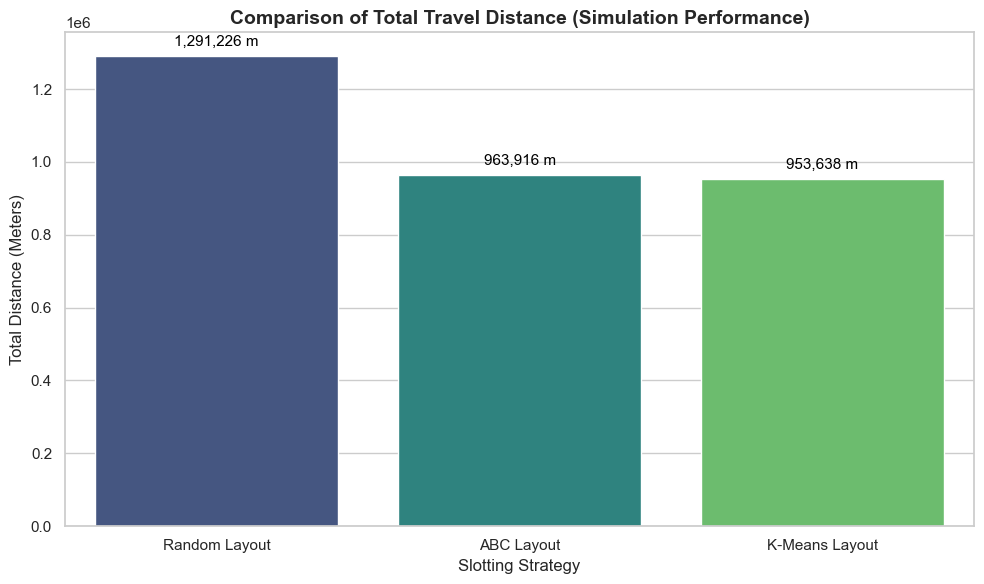

[2/3] Drawing Slotting Map (K-Means Layout)...


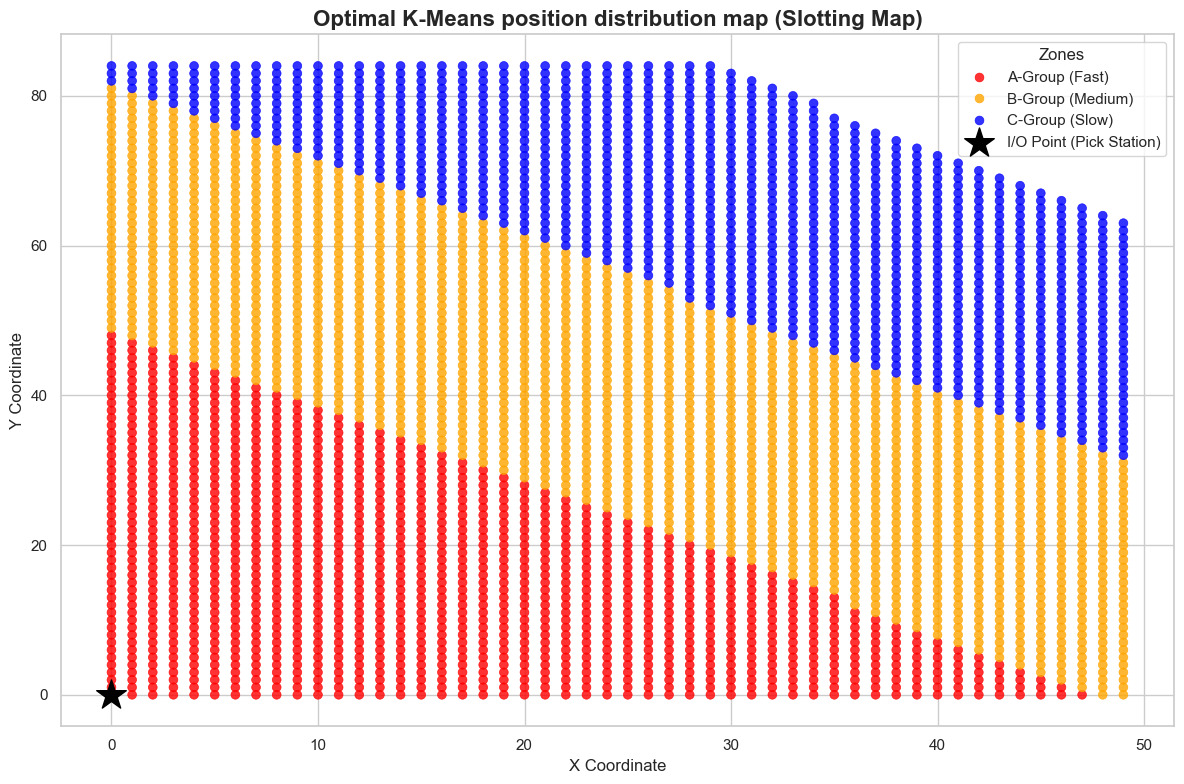

[3/3] Drawing Sankey Diagram for movement flow...


✅ Completed rendering graphics for Section 2.3! All files have been saved to: '../../outputs/images/'


In [9]:
# =====================================================================
# SECTION 2.3: VISUALIZING OPTIMIZATION RESULTS (VISUALIZATION)
# =====================================================================
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import pandas as pd

# Set up technical standard chart style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("[1/3] Drawing Bar Chart for performance comparison...")
# ---------------------------------------------------------------------
# 1. BAR CHART: TOTAL DISTANCE COMPARISON (SIMULATION PERFORMANCE)
# ---------------------------------------------------------------------
plt.figure(figsize=(10, 6))
# df_summary was calculated in Cell 4
ax = sns.barplot(x='Slotting Strategy', y='Total Distance (Meters)', data=df_summary, palette='viridis')
plt.title('Comparison of Total Travel Distance (Simulation Performance)', fontsize=14, fontweight='bold')
plt.ylabel('Total Distance (Meters)', fontsize=12)
plt.xlabel('Slotting Strategy', fontsize=12)

# Annotate values directly on top of each bar
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,} m", 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, color='black', xytext=(0, 5), 
                textcoords='offset points')
plt.tight_layout()
plt.savefig('../src/outputs/images/2_3_bar_chart_performance.png', dpi=300)
plt.show()


print("[2/3] Drawing Slotting Map (K-Means Layout)...")
# ---------------------------------------------------------------------
# 2. SLOTTING MAP: WAREHOUSE SPATIAL DISTRIBUTION
# ---------------------------------------------------------------------
# Extract coordinates from layout_kmeans dictionary to DataFrame
layout_data = [{'stock_code': sku, 'x': pos[0], 'y': pos[1]} for sku, pos in layout_kmeans.items()]
df_map = pd.DataFrame(layout_data)

# Join with df_master to get Zone labels (A/B/C) for coloring
df_map = df_map.merge(df_master[['stock_code', 'cluster_name']], on='stock_code', how='left')

plt.figure(figsize=(12, 8))
# Plot items on the grid, color by group
sns.scatterplot(x='x', y='y', hue='cluster_name', data=df_map, 
                palette={'A-Group (Fast)': 'red', 'B-Group (Medium)': 'orange', 'C-Group (Slow)': 'blue'},
                s=40, alpha=0.8, edgecolor=None)

# Mark the Pick Station (I/O Point) with a large black star
plt.scatter(io_point[0], io_point[1], color='black', marker='*', s=500, label='I/O Point (Pick Station)')

plt.title('Optimal K-Means position distribution map (Slotting Map)', fontsize=16, fontweight='bold')
plt.xlabel('X Coordinate', fontsize=12)
plt.ylabel('Y Coordinate', fontsize=12)
plt.legend(title='Zones', loc='upper right')
plt.tight_layout()
plt.savefig('../src/outputs/images/2_3_slotting_map_kmeans.png', dpi=300)
plt.show()


print("[3/3] Drawing Sankey Diagram for movement flow...")
# ---------------------------------------------------------------------
# 3. SANKEY DIAGRAM: MOVEMENT FLOW FROM ZONES TO PICK STATION
# ---------------------------------------------------------------------
# Calculate the total pick frequency of each Zone flowing to the I/O Point
zone_picks = df_master.groupby('cluster_name')['pick_frequency'].sum().reset_index()

# Flow structure for Plotly (Source -> Target)
# Zones are assigned indexes: 0, 1, 2. Pick Station assigned index: 3
labels = zone_picks['cluster_name'].tolist() + ['I/O Point (Pick Station)']
source_indices = [0, 1, 2]
target_indices = [3, 3, 3] # All flow to Pick Station
values = zone_picks['pick_frequency'].tolist()

fig = go.Figure(data=[go.Sankey(
    node = dict(
      pad = 20,
      thickness = 30,
      line = dict(color = "black", width = 0.5),
      label = labels,
      color = ["#1f77b4", "#ff7f0e", "#d62728", "#2ca02c"] # Blue, Orange, Red, Green (Station)
    ),
    link = dict(
      source = source_indices,
      target = target_indices,
      value = values,
      color = ["rgba(31,119,180,0.4)", "rgba(255,127,14,0.4)", "rgba(214,39,40,0.4)"]
    )
)])

fig.update_layout(title_text="Movement flow of pick frequency from Slot to Pick Station (Sankey Diagram)", font_size=14)
# Export HTML file so Sankey diagram retains interactive effects (Mouse hover)
fig.write_html('../src/outputs/images/2_3_sankey_diagram.html')
fig.show()

print("✅ Completed rendering graphics for Section 2.3! All files have been saved to: '../../outputs/images/'")